# Exploratory Data Analysis (EDA)

In [1]:
import os
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from PIL import Image

from tqdm import tqdm
import torchvision.transforms as T

DATASET_ROOT = "./ASL_Dataset"

TRAIN_PATH = os.path.join(DATASET_ROOT, "train")
TEST_PATH = os.path.join(DATASET_ROOT, "test")

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_pin_memory = True if device.type == "cuda" else False
use_non_blocking = True if device.type == "cuda" else False

In [2]:
class_names = sorted([
    d for d in os.listdir(TRAIN_PATH) 
    if os.path.isdir(os.path.join(TRAIN_PATH, d))
])

print(f"Classes detected: {len(class_names)}")
print(class_names)

Classes detected: 28
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'Nothing', 'O', 'P', 'Q', 'R', 'S', 'Space', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [3]:
def count_images(path):
    counts = {}
    for cls in class_names:
        folder = os.path.join(path, cls)
        counts[cls] = len(os.listdir(folder))
    return pd.DataFrame.from_dict(counts, orient='index', columns=['count'])

train_counts = count_images(TRAIN_PATH)
test_counts = count_images(TEST_PATH)

print(test_counts.head())
print(train_counts.head())

   count
A      4
B      4
C      4
D      4
E      4
   count
A   5996
B   5996
C   5996
D   5996
E   5996


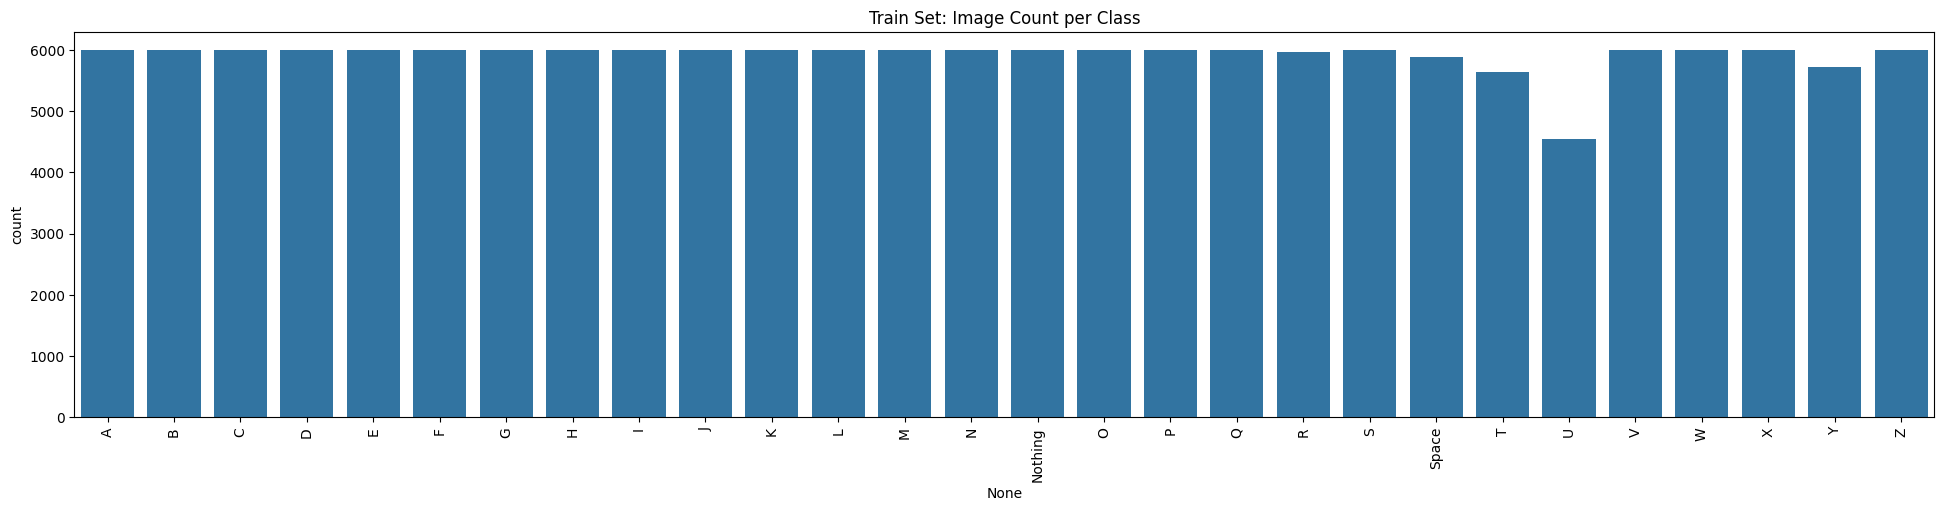

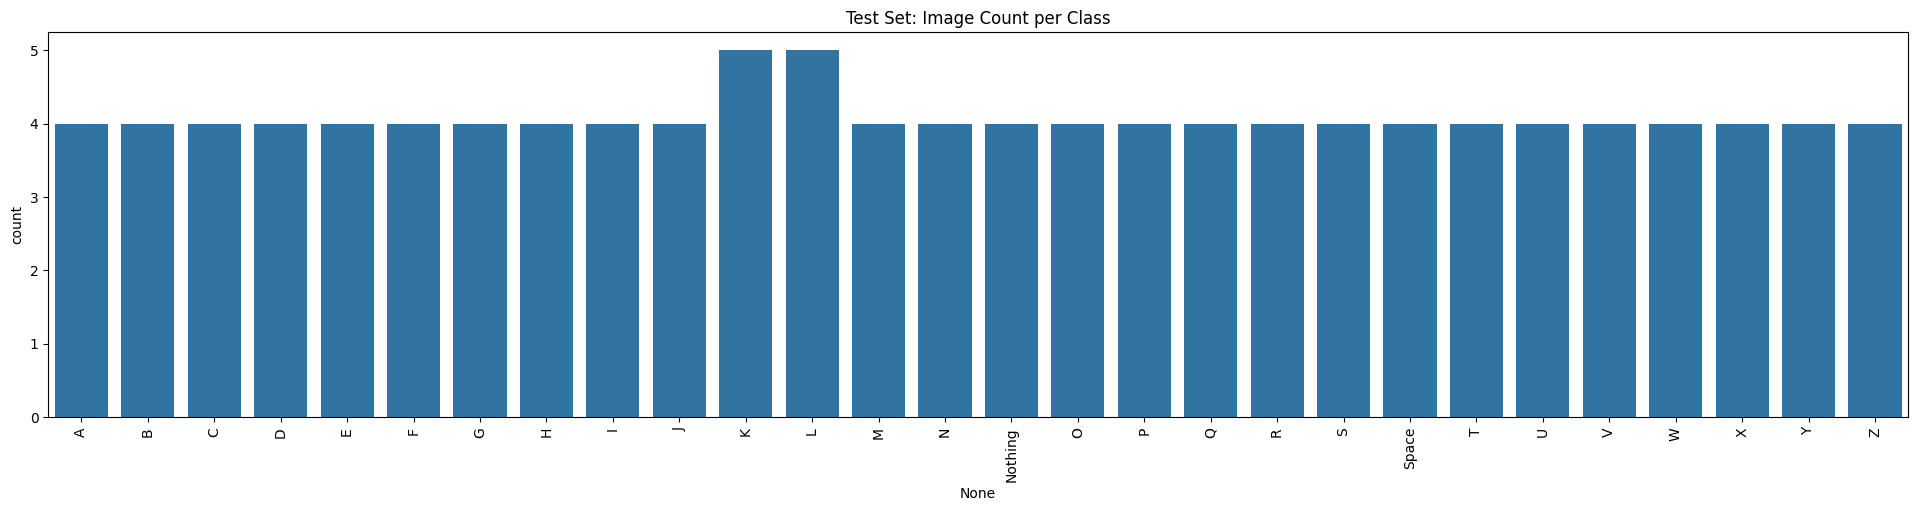

In [4]:
plt.figure(figsize=(24,5))
sns.barplot(x=train_counts.index, y=train_counts['count'])
plt.title("Train Set: Image Count per Class")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(24,5))
sns.barplot(x=test_counts.index, y=test_counts['count'])
plt.title("Test Set: Image Count per Class")
plt.xticks(rotation=90)
plt.show()

#### Inicialize datasets with labeled images

In [5]:
train_files = []
train_labels = []

for cls in class_names:
    folder = os.path.join(TRAIN_PATH, cls)
    for f in os.listdir(folder):
        train_files.append(os.path.join(folder, f))
        train_labels.append(cls)

train_df = pd.DataFrame({"filepath": train_files, "label": train_labels})

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))


Train size: 132536
Validation size: 33134


Check labels on random images

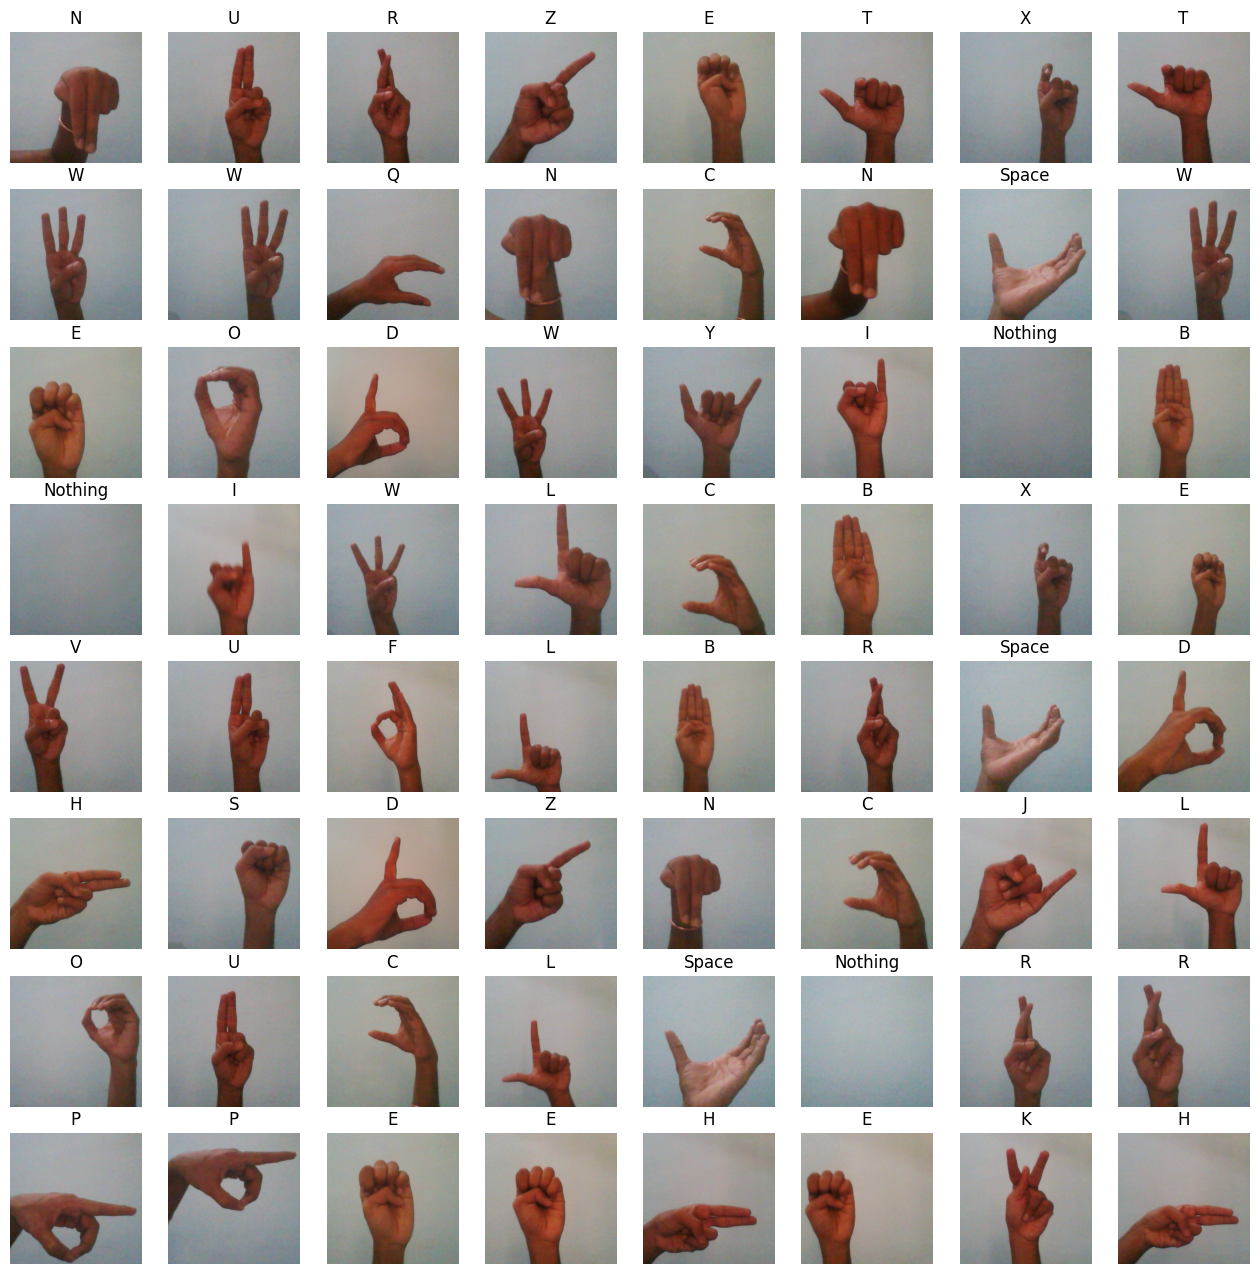

In [ ]:
def show_random_images(df, num_images=64):
    plt.figure(figsize=(16,16))
    for i in range(num_images):
        row = df.sample(1).iloc[0]
        img = Image.open(row['filepath'])

        plt.subplot(8,8,i+1)
        plt.imshow(img)
        plt.title(row['label'])
        plt.axis("off")

show_random_images(train_df)

In [7]:
sample_img = Image.open(train_df.sample(1).iloc[0]["filepath"])
img_array = np.array(sample_img)

print("Sample image shape:", img_array.shape)

Sample image shape: (400, 400, 3)


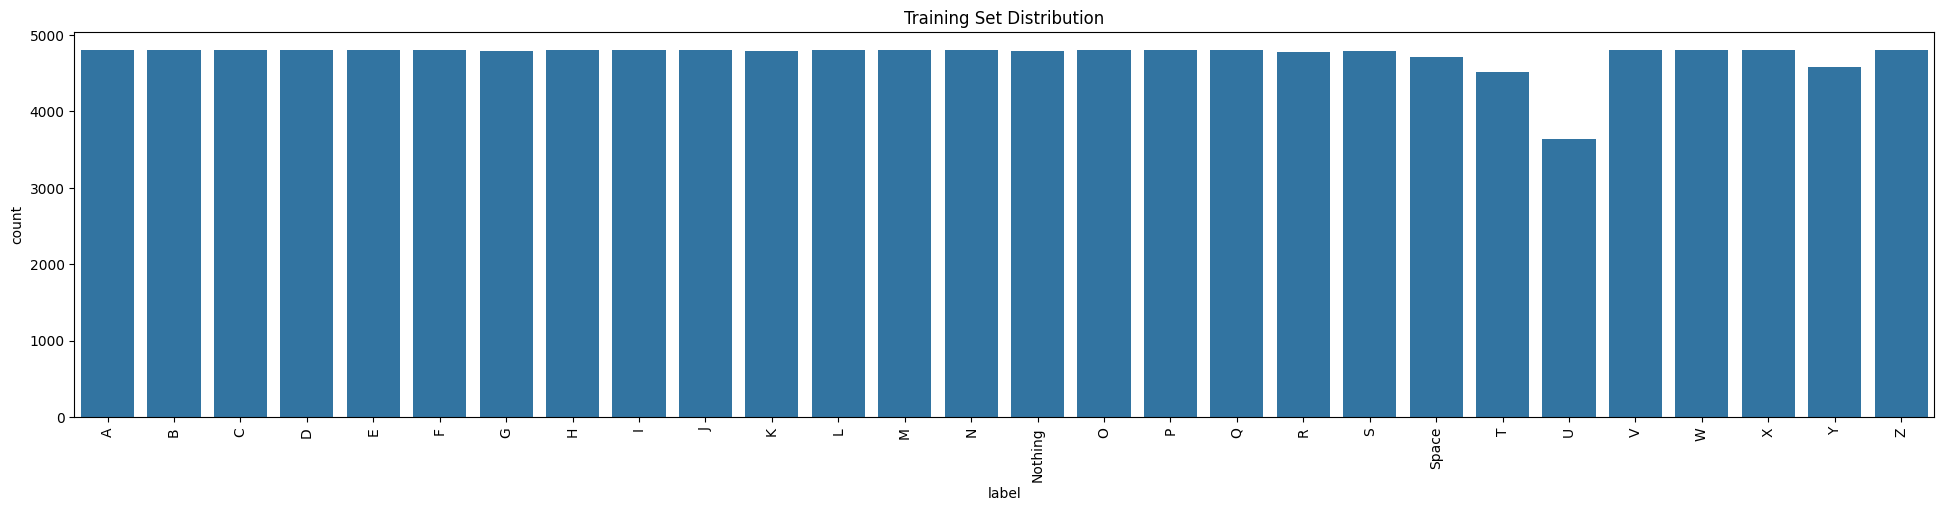

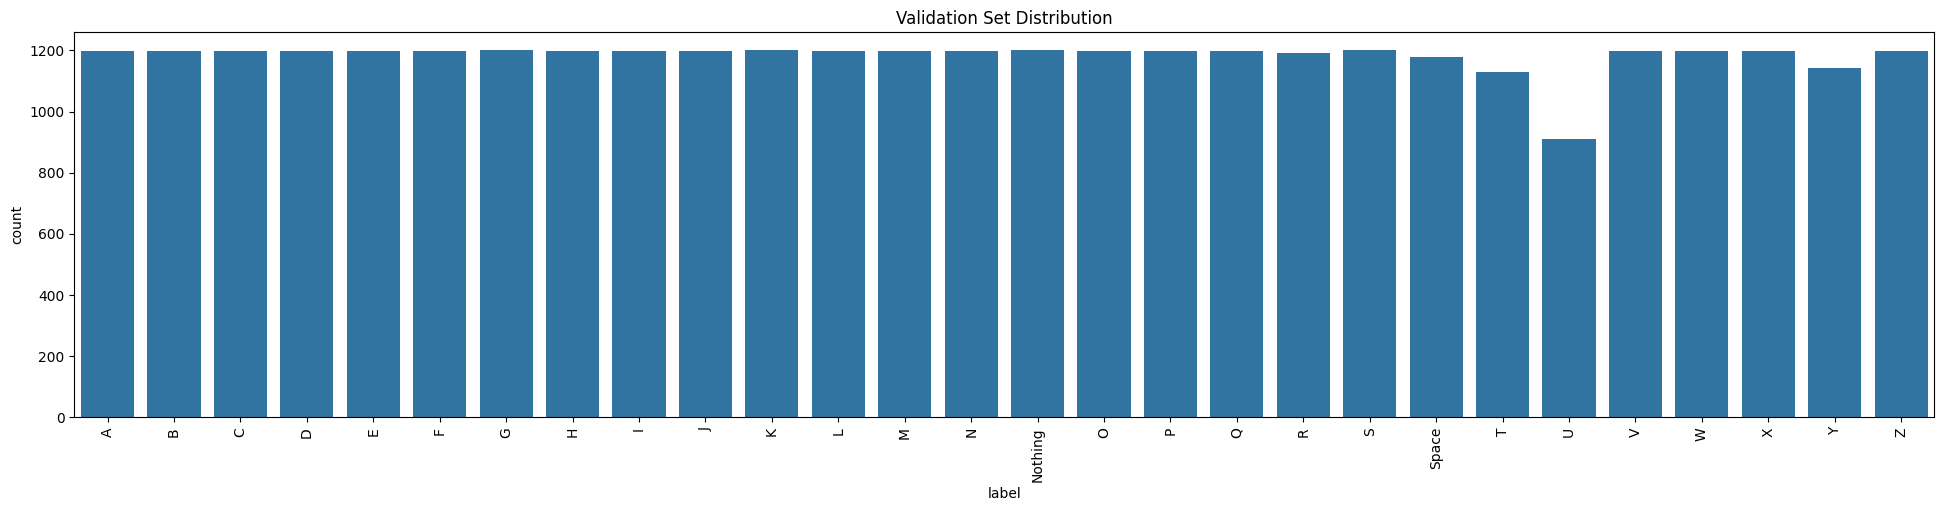

In [8]:
def plot_distribution(df, title):
    plt.figure(figsize=(24,5))
    sns.countplot(x=df['label'], order=class_names)
    plt.title(title)
    plt.xticks(rotation=90)
    plt.show()

plot_distribution(train_df, "Training Set Distribution")
plot_distribution(val_df, "Validation Set Distribution")

## DATA preprocessing

In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms   

def compute_dataset_mean_std(dataset_path, img_size, batch_size=64, use_grayscale=False, subset_ratio = 0.1):
    """Compute mean and std of a dataset."""
    
    transform_list = [transforms.Resize((img_size, img_size))]
    if use_grayscale:
        transform_list.append(transforms.Grayscale(num_output_channels=1))
    transform_list.append(transforms.ToTensor())  # scale 0-1
    transform = transforms.Compose(transform_list)

    dataset = datasets.ImageFolder(dataset_path, transform=transform)

    if subset_ratio < 1.0:
        subset_size = int(len(dataset) * subset_ratio)
        subset_indices = random.sample(range(len(dataset)), subset_size)
        dataset = Subset(dataset, subset_indices)
        print(f"Using subset of {subset_size} images out of {len(dataset)} total.")
    else:
        print(f"Using full dataset of {len(dataset)} images.")

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    mean = 0.
    std = 0.
    total_images = 0

    for images, _ in loader:
        batch_samples = images.size(0)
        images = images.view(batch_samples, images.size(1), -1)  # flatten H*W
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images += batch_samples
        
    mean /= total_images
    std /= total_images

    return mean, std


In [14]:
IMG_SIZE = 32

USE_GRAYSCALE = False

MEAN, STD = compute_dataset_mean_std("./ASL_Dataset", IMG_SIZE, use_grayscale=USE_GRAYSCALE)
print(MEAN, STD)

Using subset of 16578 images out of 16578 total.
tensor([0.5620, 0.5302, 0.5135]) tensor([0.0941, 0.1547, 0.1729])


Torch data transformation pipeline

In [ ]:
from torchvision.transforms import v2 # for CPU

base_preprocess = [
    T.Resize((IMG_SIZE, IMG_SIZE))
]

base_process_cpu = [
    v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)]),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ConvertImageDtype(torch.float32),
]

if USE_GRAYSCALE:
    base_preprocess.append(T.Grayscale(num_output_channels=1))
    base_process_cpu.append(v2.Grayscale(num_output_channels=1))

train_transform = v2.Compose([
    *base_process_cpu,
    v2.Normalize(mean=MEAN, std=STD),
])

eval_transforms = T.Compose([
    *base_preprocess,
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

In [ ]:
from torch.utils.data import Dataset
# can't load using Image folder so custom implementation is required

class ASLFrameDataset(Dataset):
    def __init__(self, df, transform=None, class_to_idx=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row["label"]]
        
        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
from torchvision.datasets import ImageFolder
class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

train_dataset =  ASLFrameDataset(
    df=train_df,
    transform=train_transform,
    class_to_idx=class_to_idx)

val_dataset = ASLFrameDataset(
    df=val_df,
    transform=eval_transforms,
    class_to_idx=class_to_idx
)

In [20]:
from torchvision.datasets import ImageFolder

test_dataset = ImageFolder(
    root=TEST_PATH,
    transform=eval_transforms
)

NameError: name 'eval_transforms' is not defined

In [ ]:
from torch.utils.data import DataLoader

BATCH_SIZE = 128
NUM_WORKERS = 0

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False # for gpu 
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False
)

Visual debug check 

In [ ]:
def show_batch(dataloader, n=8):
    images, labels = next(iter(dataloader))

    images = images[:n]
    labels = labels[:n]

    plt.figure(figsize=(12,3))
    for i in range(n):
        img = images[i].numpy().transpose(1,2,0)

        img = img * np.array(STD) + np.array(MEAN)
        img = np.clip(img, 0, 1)

        plt.subplot(1,n,i+1)
        if USE_GRAYSCALE:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.title(list(class_to_idx.keys())[labels[i]])
        plt.axis("off")

show_batch(train_loader)

# Model traning

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes, grayscale=True):
        super().__init__()
        in_channels = 1 if grayscale else 3

        self.conv1 = nn.Conv2d(in_channels, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)

        # 32 -> 16 -> 8
        self.fc1 = nn.Linear(16*8*8, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [ ]:
num_classes = len(class_names)
model = VSL_CNN(num_classes, grayscale=USE_GRAYSCALE).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
num_epochs = 1

for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    
    # Wrap train_loader with tqdm
    loop = tqdm(train_loader, leave=True)
    for imgs, labels in loop:
        imgs, labels = imgs.to(device, non_blocking=use_non_blocking), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        
        # Update tqdm description
        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=running_loss/total*BATCH_SIZE, acc=correct/total)


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    loop = tqdm(val_loader, leave=False)
    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
        loop.set_postfix(val_acc=correct/total)

print(f"Validation Accuracy: {correct/total:.4f}")


In [ ]:
model.eval()  # set model to evaluation mode
correct = 0
total = 0

with torch.no_grad():  # no gradients needed for testing
    for imgs, labels in tqdm(test_loader, desc="Testing"):
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (preds == labels).sum().item()

test_acc = correct / total
print(f"Test Accuracy: {test_acc:.4f}")


# Experimenting